In [3]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [4]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/CLUSTERING/data_v01_clustering_ventas.csv'

dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/CLUSTERING/data_v02_clustering_limpio_ramon_v2.csv'

In [6]:
#cargamos el dataset y mostramos las primeras filas
try:
    df = pd.read_csv(dataset)
    print(f"Archivo {dataset} cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/CLUSTERING/data_v02_clustering_limpio_ramon_v2.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom,20.34


In [7]:
import pandas as pd
import numpy as np


print(f"Filas originales antes de limpieza: {len(df)}")

# FASE 1: LIMPIEZA DE DATOS. NO NECESARIA EN ESTE DATASET

"""
# Eliminar CustomerID nulos
df_clean = df.dropna(subset=['CustomerID']).copy()

# Eliminar Descripciones nulas
df_clean = df_clean.dropna(subset=['Description'])

# Eliminar Invoices Canceladas (Nos quedamos solo con las ventas)
# Asumimos que las cancelaciones tienen Quantity negativa o empiezan por 'C' en el InvoiceNo
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Convertir CustomerID a string
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

# Convertir la fecha
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Calcular el TotalPrice de cada línea
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Eliminar las variables de regresión

# NO BORRO de momento: 'IsUk', 'DayOfWeek','IsWeekend'
columnas_regresion = ['Sales_Lag_1', 'Sales_Lag_7', 'Sales_Mean_7', 'Sales_Mean_30', 'dayOfweek', 'is_weekend', 'DailyTotal', 'Trend_Lag1_vs_Lag7']
columnas_a_borrar = [col for col in columnas_regresion if col in df_clean.columns]

if columnas_a_borrar:
    df_clean = df_clean.drop(columns=columnas_a_borrar)
    print(f"Columnas eliminadas: {columnas_a_borrar}")

print(f"Filas resultantes tras limpieza: {len(df_clean)}")
display(df_clean.head())
"""

df_clean = df.copy()
display(df_clean)

Filas originales antes de limpieza: 390600


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
390595,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,12680,France,10.20
390596,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680,France,12.60
390597,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680,France,16.60
390598,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680,France,16.60


#  FEATURE ENGINEERING


- **averageOrderValues**: valor medio de las compras. distingue al cliente que hace muchas compras (mucha frecuencia) y poca cantidad del cliente que compra poco y pero gasta mucho.

- **AvgQuantityPerOrder**: media de Quantity por factura. Detecta compradores mayoristas vs minoristas - Cluster de”Grandes compradores”

- valor total de las compras
- valor mensual de las compras


In [8]:
import pandas as pd
import numpy as np

# Convert InvoiceDate to datetime objects
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


""" IOAN
# 1. Preparación de variables temporales en el dataset limpio
fecha_referencia = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['Is_Weekend'] = np.where(df_clean['DayOfWeek'] >= 5, 1, 0)

# 2. Agrupación y creación de variables Core
df_usuarios = df_clean.groupby('CustomerID').agg({
    # RFM Básico
    'InvoiceDate': ['max', 'min'],                                    # Para Recency y Tenure
    'InvoiceNo': 'nunique',                                           # Frequency
    'TotalPrice': 'sum',                                              # Monetary

    # Diversidad y Volumen
    'StockCode': 'nunique',                                           # UniqueProducts
    'Quantity': 'sum',                                                # TotalQuantity

    # Patrones temporales y geografía
    'Is_Weekend': 'mean',                                             # % de compras en finde
    'DayOfWeek': lambda x: x.mode()[0] if not x.mode().empty else 0,  # Día favorito
    'Country': 'first'                                                # Para Is_UK
}).reset_index()

display(df_usuarios);

# Aplanamos los nombres de las columnas que vienen de usar varios aggregates
df_usuarios.columns = ['CustomerID', 'LastPurchase', 'FirstPurchase', 'Frequency',
                       'Monetary', 'UniqueProducts', 'TotalQuantity',
                       'Weekend_Ratio', 'Favorite_Day', 'Country']

print('Después de aplanar')
display(df_usuarios);
"""


####### Creación de métricas base (RFM y Totales)

# Definimos la fecha de referencia (el "hoy" del dataset)
reference_date = df_clean['InvoiceDate'].max() # Recency

customer_df = df_clean.groupby('CustomerID').agg({
    # RFM Básico
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Días desde última compra (RECENCY)
  # 'InvoiceDate': ['max', 'min'],    # IOAN Para crear columnas 'LastPurchase' (Recency), 'FirstPurchase', (Tenure)
    'InvoiceNo': 'nunique',     # Frecuency: Frecuencia de pedidos
    'TotalPrice': 'sum',        # Monetary: Valor Monetario total

    # Diversidad y Volumen
    'StockCode': 'nunique',     # UniqueProducts. # Objetivo: Saber si el cliente es fiel a un solo producto o explora el catálogo.
    'Quantity': 'sum'          # Unidades totales compradas

    # Patrones temporales y geografía
  # 'Is_Weekend': 'mean',    # IOAN % de compras en finde -> "Weekend_Ratio"
  # 'DayOfWeek': lambda x: x.mode()[0] if not x.mode().empty else 0,  # "Favourite_day"
  # 'Country': 'first' -   # IOAN Añade los paises con texto de nuevo. NO HACE FALTA ya que tenemos ya is_UK con 0-1

}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary',
    'StockCode': 'UniqueProducts',
    'Quantity': 'TotalQuantity'
})


# Feature Engineering: Columnas calculadas para el modelo
# ---------------------------------------------------------

# 0. Tenure: Días desde la primera compra hasta la fecha de referencia
# Primero, calculamos la fecha de la PRIMERA compra de cada cliente
first_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].min()
customer_df['Tenure'] = (reference_date - first_purchase).dt.days


# 1. Valor medio de las compras (Ticket Promedio)
# Objetivo: Identificar si el cliente es de alto o bajo perfil por pedido.
customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']


# 2. Media de cantidad por pedido
# Objetivo: Diferenciar compradores minoristas de mayoristas (B2B).
customer_df['AvgQuantityPerOrder'] = customer_df['TotalQuantity'] / customer_df['Frequency']


# 3. Valor mensual de las compras
# Calculamos los meses totales que cubre el dataset para normalizar el gasto.
days_range = (df_clean['InvoiceDate'].max() - df_clean['InvoiceDate'].min()).days
print(f'\n Rango de días totales en el dataset', days_range)
print('\n')
months_range = max(1, days_range / 30.44) # Promedio de días que tiene un mes en un año (365.25 / 12 = 30.44).
customer_df['MonthlySpending'] = customer_df['Monetary'] / months_range


## IOAN ES El mismo que "uniqueProduct"
customer_df['Products_Per_Order'] = customer_df['UniqueProducts'] / customer_df['Frequency']

# 5. Intervalo de compra estimado (cada cuántos días compra)
customer_df['PurchaseInterval'] = days_range / customer_df['Frequency']


########## Visualización del dataset resultante
print("Nuevas columnas para Clustering:")
display(customer_df)

# Guardar el dataset procesado para el siguiente paso del modelo
# customer_df.to_csv('data_for_clustering.csv')


 Rango de días totales en el dataset 373


Nuevas columnas para Clustering:


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,MonthlySpending,Products_Per_Order,PurchaseInterval
CustomerID,,,,,,,,,,,
12347,2,7,"4,310.00",103,2458,367,615.71,351.14,351.73,14.71,53.29
12348,75,4,"1,437.24",21,2332,358,359.31,583.00,117.29,5.25,93.25
12349,18,1,"1,457.55",72,630,18,"1,457.55",630.00,118.95,72.00,373.00
12350,310,1,294.40,16,196,310,294.40,196.00,24.03,16.00,373.00
12352,36,7,"1,385.74",57,526,296,197.96,75.14,113.09,8.14,53.29
...,...,...,...,...,...,...,...,...,...,...,...
18280,277,1,180.60,10,45,277,180.60,45.00,14.74,10.00,373.00
18281,180,1,80.82,7,54,180,80.82,54.00,6.60,7.00,373.00
18282,7,2,178.05,12,103,126,89.03,51.50,14.53,6.00,186.50


Notas sobre el código:

- **Frequency**: Frecuencia de pedidos

- **Monetary**: Valor Monetario total

Son los pilares. Un cliente con **alta frecuencia** pero **bajo valor monetario** es un "comprador hormiga".

- **Recency**: Es vital para **DBScan**; si un grupo de puntos tiene una recencia muy alta, el modelo los agrupará como clientes inactivos o "en fuga".

- **UniqueProducts**: Añade una dimensión de "comportamiento de exploración". Ayuda a los modelos de clustering a separar a los especialistas (que compran siempre lo mismo) de los generalistas.

La **combinación de Tenure (Antigüedad) y Recency (Recencia)** es oro puro para los algoritmos:

- Tenure alto + Recency bajo: Es un cliente leal y activo (el mejor).

- Tenure bajo + Recency bajo: Es un cliente nuevo (potencial a fidelizar).

- Tenure alto + Recency alto: Era un cliente fiel que hemos perdido (perfecto para campañas de reactivación).

- Tenure bajo + Recency alto: Probablemente alguien que probó una vez y no volvió.

# Matriz de correlación de Pearson


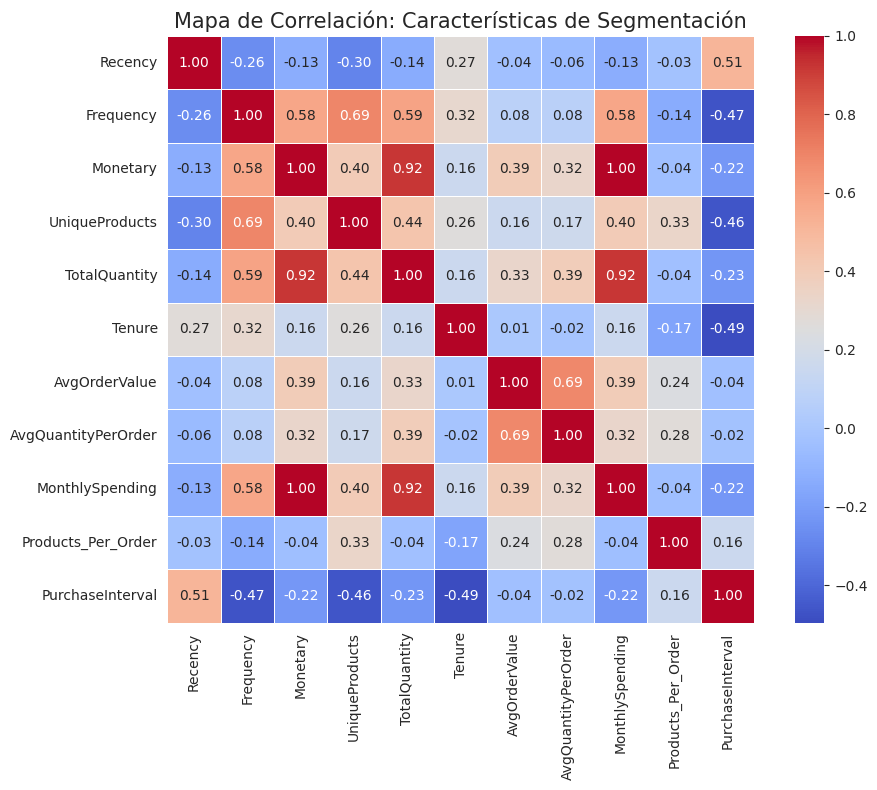

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

########. Generación del Mapa de Correlación

# Calculamos la matriz de correlación de Pearson
corr_matrix = customer_df.corr()

# Configuración visual del gráfico
plt.figure(figsize=(10, 8))

# Crear el heatmap con Seaborn
sns.heatmap(corr_matrix,
            annot=True,           # Muestra los valores numéricos
            cmap='coolwarm',      # Escala de color: Rojo (Positivo), Azul (Negativo)
            fmt=".2f",            # Redondear a 2 decimales
            linewidths=0.5,       # Línea divisoria entre cuadros
            square=True)          # Cuadros perfectamente cuadrados

plt.title('Mapa de Correlación: Características de Segmentación', fontsize=15)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

La matriz de correlación es nuestra brújula estratégica antes del entrenamiento.

Esta herramienta nos dice exactamente qué sobra.

Vemos variables con relación fuerte, cercanas a  1:

- **Monetary y MonthlySpending** tienen una correlación de **1.00**. Esto significa que son la misma variable con distinto nombre. Debemos eliminar una para no sesgar el algoritmo hacia el valor monetario.

- **MonthlySpending y TotalQuantity** tienen un **0.92**. Esto sugiere que, para simplificar el modelo, podríamos quedarnos solo con una.

Eliminamos "monthlySpending" ya que "choca" con las otras dos variables.



In [10]:

# Limpieza final de columnas base que ya que tienen correlacción muy alta (cercana a 1)
columnas_a_borrar = ['MonthlySpending']
customer_df = customer_df.drop(columns=columnas_a_borrar)

display(customer_df)


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval
CustomerID,,,,,,,,,,
12347,2,7,"4,310.00",103,2458,367,615.71,351.14,14.71,53.29
12348,75,4,"1,437.24",21,2332,358,359.31,583.00,5.25,93.25
12349,18,1,"1,457.55",72,630,18,"1,457.55",630.00,72.00,373.00
12350,310,1,294.40,16,196,310,294.40,196.00,16.00,373.00
12352,36,7,"1,385.74",57,526,296,197.96,75.14,8.14,53.29
...,...,...,...,...,...,...,...,...,...,...
18280,277,1,180.60,10,45,277,180.60,45.00,10.00,373.00
18281,180,1,80.82,7,54,180,80.82,54.00,7.00,373.00
18282,7,2,178.05,12,103,126,89.03,51.50,6.00,186.50


## Eliminar los valores de la columna customerID




In [19]:

####### Quitar los valores de la columna customerID, ya que solo meterá ruido
# CustomerID actualmente es el index del dataframe, por lo que reseteamos index para que sea primera columna
customer_df_temp = customer_df.reset_index()
#print(customer_df_temp);

clientes_id = customer_df_temp['CustomerID']
#display(clientes_id);

df_modelo = customer_df_temp.drop(columns=['CustomerID'])
#display(df_modelo);



# Detección de outliers




In [21]:
from sklearn.ensemble import IsolationForest

#  DETECCIÓN DE OUTLIERS CON ISOLATION FOREST

# Isolation Forest detecta clientes con patrones muy diferentes al resto.
# En este caso se marca aproximadamente un 5% de clientes como outliers.
# Estos clientes no se eliminan definitivamente: se guardan aparte para análisis posterior.

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = iso.fit_predict(df_modelo)

# En Isolation Forest:
#  1 = cliente normal
# -1 = cliente outlier
mask_normales = outlier_labels == 1

print("Clientes totales antes de outliers:", df_modelo.shape[0])
print("Clientes normales:", mask_normales.sum())
print("Clientes outliers detectados:", (outlier_labels == -1).sum())
print("Porcentaje outliers:", round((outlier_labels == -1).sum() / df_modelo.shape[0] * 100, 2), "%")

# Guardar los outliers para análisis posterior
df_outliers = df_modelo.loc[~mask_normales].copy()
df_outliers["Outlier_Label"] = -1

# Filtrar clientes normales para el clustering principal
X_modelo_normales = df_modelo.loc[mask_normales].copy()
clientes_id_normales = clientes_id.loc[mask_normales].copy()

print("\nDimensiones tras eliminar outliers:")
print(X_modelo_normales.shape)

display(df_outliers.head())


Clientes totales antes de outliers: 4333
Clientes normales: 4116
Clientes outliers detectados: 217
Porcentaje outliers: 5.01 %

Dimensiones tras eliminar outliers:
(4116, 11)


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,Cluster,Outlier_Label
CustomerID,,,,,,,,,,,,
12349,18,1,"1,457.55",72,630,18,"1,457.55",630.00,72.00,373.00,0,-1
12357,33,1,"6,207.67",131,2708,33,"6,207.67","2,708.00",131.00,373.00,0,-1
12378,129,1,"4,008.62",219,2529,129,"4,008.62","2,529.00",219.00,373.00,0,-1
12398,45,1,"1,435.66",84,1389,45,"1,435.66","1,389.00",84.00,373.00,0,-1
12406,22,2,"3,415.30",92,1818,183,"1,707.65",909.00,46.00,186.50,0,-1


# Normalización y escalado


In [24]:
from sklearn.preprocessing import RobustScaler
import pandas as pd


df_modelo = X_modelo_normales.copy()


# 1. Variables categóricas en las que usarás one-hot-encoding

######### No hay ninguna columna con datos categóricos !!!


# Definimos la lista de columnas numéricas que requieren escalado
numeric_cols = [
    'Recency', 'Frequency', 'Monetary', 'UniqueProducts',
    'TotalQuantity', 'AvgOrderValue', 'AvgQuantityPerOrder',
    'Tenure', 'Products_Per_Order', 'PurchaseInterval'
]

# Filtrar numeric_cols para solo incluir estos en el dataframe para ENTRENAMIENTO MODELO
numeric_cols = [col for col in numeric_cols if col in df_modelo.columns]


# Inicializar el método de escalado habitual RobustScaler
scaler = RobustScaler()

# 2. Escalar todas las variables numéricas para situarlas en un mismo rango
# Utilizamos fit_transform para ajustar el escalador y transformar los datos en un solo paso
df_modelo[numeric_cols] = scaler.fit_transform(df_modelo[numeric_cols])

print("Dataset normalizado y escalado:")
display(df_modelo)

Dataset normalizado y escalado:


,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,Cluster
CustomerID,,,,,,,,,,,
12347,-0.38,1.67,3.25,1.21,2.98,0.57,1.49,1.19,0.04,-0.48,0
12348,0.18,0.67,0.72,-0.23,2.80,0.53,0.36,2.60,-0.55,-0.33,0
12350,1.98,-0.33,-0.29,-0.32,-0.21,0.30,0.08,0.25,0.12,0.67,0
12352,-0.12,1.67,0.67,0.40,0.25,0.24,-0.34,-0.48,-0.37,-0.48,0
12353,1.17,-0.33,-0.47,-0.53,-0.46,-0.19,-0.82,-0.81,-0.62,0.67,0
...,...,...,...,...,...,...,...,...,...,...,...
18280,1.73,-0.33,-0.39,-0.42,-0.43,0.15,-0.42,-0.66,-0.25,0.67,0
18281,0.98,-0.33,-0.48,-0.47,-0.41,-0.30,-0.86,-0.61,-0.44,0.67,0
18282,-0.35,0.00,-0.39,-0.39,-0.34,-0.56,-0.82,-0.62,-0.50,0.00,0


# Buscar número óptimo de clusters (K) para entrenamiento modelos


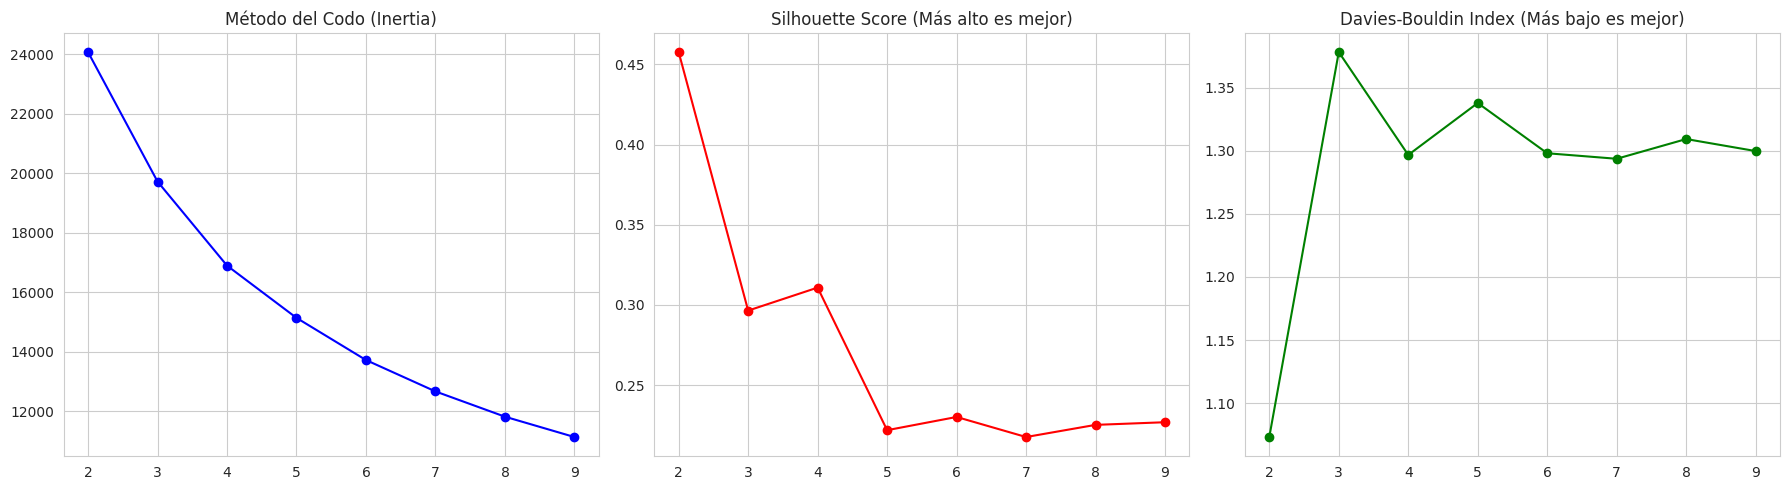

In [25]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

X_train = df_modelo.copy()

# Se calculan métricas para un rango de clusters (2 a 10)
inertia = []
sil_scores = []
db_indices = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train, labels))
    db_indices.append(davies_bouldin_score(X_train, labels))

# Visualización de métricas de diagnóstico
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(K_range, inertia, 'bo-')
ax[0].set_title('Método del Codo (Inertia)')
ax[1].plot(K_range, sil_scores, 'ro-')
ax[1].set_title('Silhouette Score (Más alto es mejor)')
ax[2].plot(K_range, db_indices, 'go-')
ax[2].set_title('Davies-Bouldin Index (Más bajo es mejor)')
plt.tight_layout()
plt.show()

# ENTRENAMIENTO COMPARATIVO DE MODELOS


In [13]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def visualizar_tsne(model_name, X_train, labels, perplexity=30, n_iter=1000):
    """
    Realiza la reducción t-SNE y genera un gráfico 2D.
    """
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)
    X_tsne = tsne.fit_transform(X_train)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=35, alpha=0.7)
    plt.colorbar(scatter, label='Cluster')
    plt.title(f"{model_name} - Visualización t-SNE 2D", fontsize=15, fontweight='bold')
    plt.xlabel('Eje t-SNE 1')
    plt.ylabel('Eje t-SNE 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return X_tsne

def visualizar_pca_3d_estatico(model_name, X_train, labels):
    """
    Reduce a 3 componentes con PCA y muestra un gráfico 3D estático (Matplotlib).
    """
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_train)

    # Calculamos la varianza explicada
    varianza_explicada = pca.explained_variance_ratio_.sum() * 100
    print(f"-> Varianza explicada por los 3 componentes: {varianza_explicada:.2f}%")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='viridis', s=30, alpha=0.6)

    ax.set_title(f'{model_name}: PCA 3D - Estático', fontsize=15)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.set_zlabel('Componente 3')
    plt.show()

    return X_pca


def visualizar_pca_3d_interactivo(model_name, X_train, labels):
    """
    Crea un scatter plot 3D interactivo
    """
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_train)

    # Calculamos la varianza explicada
    varianza_explicada = pca.explained_variance_ratio_.sum() * 100
    print(f"-> Varianza explicada por los 3 componentes: {varianza_explicada:.2f}%")

    # Creamos un DataFrame temporal para Plotly
    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
    df_pca['Cluster'] = labels.astype(str) # Convertimos a string para colores discretos

    fig = px.scatter_3d(
        df_pca, x='PC1', y='PC2', z='PC3',
        color='Cluster',
        title=f"{model_name}: PCA 3D Interactivo",
        opacity=0.7
    )

    fig.show()

In [14]:
def train_models(models, X_train):
  final_results = []

  for name, model in models.items():
    labels = model.fit_predict(X_train)

    """
      Si el modelo te devuelve estas labels: [0, 0, 1, 1, 1, -1, -1]
        - Unicos: {0, 1, -1} (Hay 3 tipos de etiquetas).
        - ¿Hay ruido?: Sí, si algun -1.
        - Cálculo: 3 - 1 = 2.
      Resultado final: El código te dirá que hay 2 clusters, ignorando los puntos marcados como ruido. Es una forma elegante de obtener el número de grupos "reales" detectados automáticamente.
    """
    mask = labels != -1     # Para métricas de clusters en DBSCAN, excluimos el ruido (-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Validamos que existan al menos 2 clusters para calcular métricas
    if n_clusters > 1:
        sil = silhouette_score(X_train[mask], labels[mask])
        db = davies_bouldin_score(X_train[mask], labels[mask])
        final_results.append({
            'Modelo': name,
            'Clusters Detectados': n_clusters,
            'Silhouette': round(sil, 4),
            'Davies-Bouldin': round(db, 4),
            'etiquetas': labels
        })

        # VISUALIZACIONES
        visualizar_tsne(name, X_train, labels, perplexity=30, n_iter=1000)
        visualizar_pca_3d_interactivo(name, X_train, labels)

    else:
        final_results.append({
            'Modelo': name,
            'Clusters Detectados': n_clusters,
            'Silhouette': 'N/A',
            'Davies-Bouldin': 'N/A'
        })


  # Resultado Final en DataFrame
  df_comparativa = pd.DataFrame(final_results)
  print(df_comparativa)

  return final_results


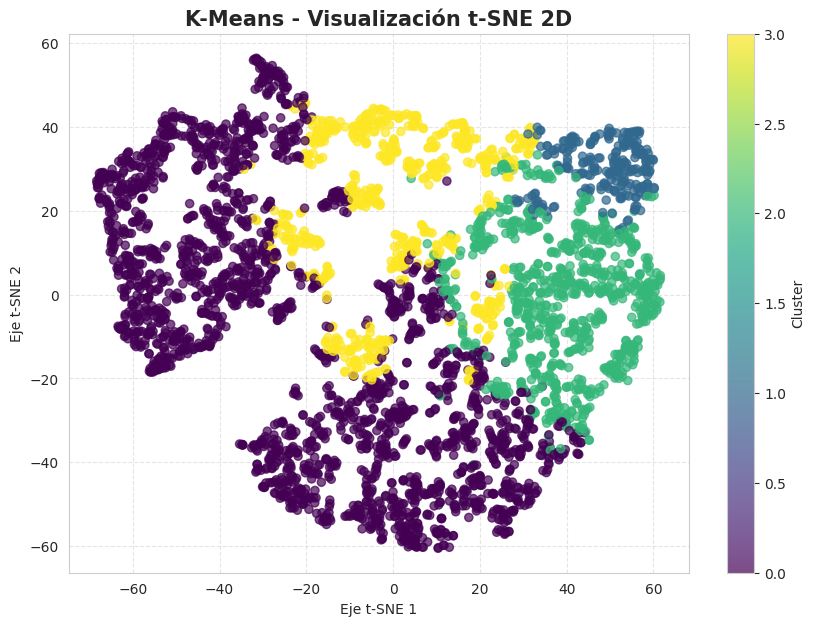

-> Varianza explicada por los 3 componentes: 83.77%


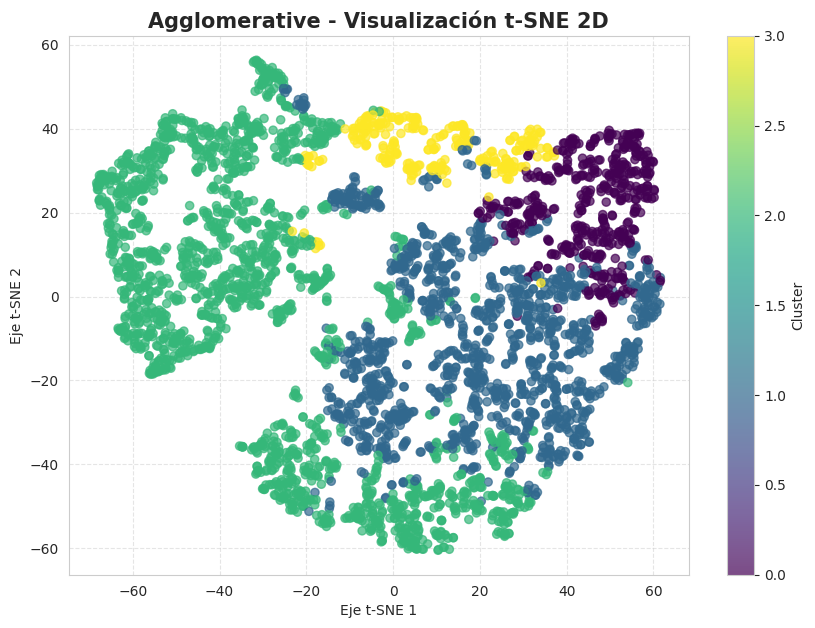

-> Varianza explicada por los 3 componentes: 83.77%


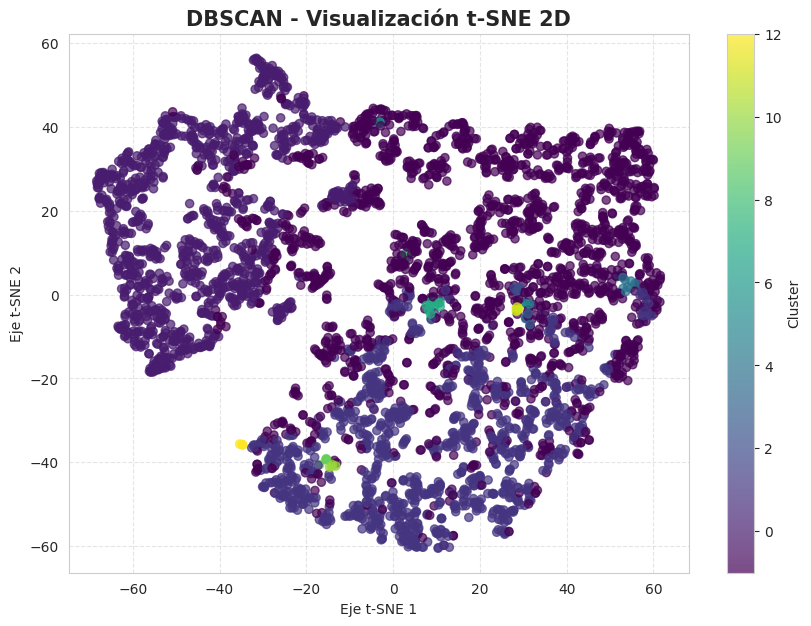

-> Varianza explicada por los 3 componentes: 83.77%


          Modelo  Clusters Detectados  Silhouette  Davies-Bouldin                                          etiquetas
0        K-Means                    4        0.31            1.30  [1, 2, 0, 2, 0, 3, 0, 3, 0, 1, 3, 0, 1, 0, 2, ...
1  Agglomerative                    4        0.20            1.49  [0, 1, 2, 1, 2, 3, 2, 3, 2, 3, 3, 2, 0, 1, 1, ...
2         DBSCAN                   13       -0.11            1.02  [-1, -1, 0, 1, 0, -1, 0, -1, -1, -1, -1, 0, -1...


In [27]:

K = 4;

# Configuramos los tres modelos solicitados
models = {
    'K-Means': KMeans(n_clusters=K, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=K),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5) # Parámetros ajustables según densidad
}

models_results = train_models(models, X_train);

### interpretación técnica de lo que está ocurriendo con tus datos:


## SEGUNDA PRUEBA con k=4, mejor resultados desde punto vista comercial:

Lo que ha ocurrido es que el algoritmo ha decidido "fragmentar" el grupo mayoritario (la masa de clientes) para intentar encontrar matices.

¿Es mejor? Desde un punto de vista comercial, sí, porque te permite diferenciar entre clientes que están "vivos" y clientes que probablemente ya has perdido.

---

## PRIMERA PRUEBA HICE ESTOS RESULTADOS con K=3

| Modelo        | Clusters | Silhouette | Davies-Bouldin |
|--------------|----------|------------|----------------|
| K-Means      | 3        | 0.92       | 0.68           |
| Agglomerative| 3        | 0.90       | 0.67           |
| DBSCAN       | 18       | -0.17      | 0.94           |

---

1. **K-Means y Agglomerative (Los ganadores)**
Ambos modelos presentan métricas excelentes y muy similares:

Silhouette (0.90 - 0.92): Es una puntuación altísima. Indica que los 3 clusters están extremadamente bien definidos, con una gran distancia entre ellos y mucha cohesión interna.

Davies-Bouldin (0.67 - 0.68): Al ser un valor bajo, confirma que los grupos no están solapados.

Conclusión: Tus datos tienen una estructura natural de 3 grupos muy marcada que ambos algoritmos han captado perfectamente.


2. **El problema con DBSCAN**
Los resultados de DBSCAN (18 clusters y un Silhouette negativo de -0.17) indican que el modelo ha fallado en encontrar la estructura global:

Silhouette Negativo: Un valor por debajo de 0 significa que muchos puntos han sido asignados al cluster equivocado o que los clusters están tan solapados que no tienen sentido.

Exceso de Clusters: Detectar 18 grupos sugiere que DBSCAN está siendo demasiado sensible al "ruido" o a pequeñas variaciones de densidad locales, perdiendo de vista los 3 grandes grupos principales.

Causa probable: DBSCAN es muy sensible a los parámetros eps (distancia) y min_samples. Con los valores actuales, está fragmentando los datos en pedazos pequeños en lugar de agruparlos.

## Mejorar DBScan

In [28]:
# --- TÉCNICA DE MEJORA: TRANSFORMACIÓN LOGARÍTMICA ---
# DBSCAN sufre cuando hay mucha diferencia de densidad. El logaritmo "aplasta"
# los valores grandes (outliers) y acerca a los clientes entre sí.

# features = ['Monetary', 'Frequency', 'Recency', 'AvgOrderValue', 'Tenure']
X_log = df_modelo.copy()

# Aplicamos log(1+x) para manejar ceros y normalizar la distribución
for col in numeric_cols:
    X_log[col] = np.log1p(X_log[col])

# Imputamos los valores NaN que puedan haber surgido de la transformación logarítmica
# Esto es crucial porque DBSCAN no puede manejar NaNs.
X_log.fillna(X_log.median(), inplace=True)

# 2. ESCALADO ROBUSTO
scaler = RobustScaler()
X_scaled_log = scaler.fit_transform(X_log)

# 3. ENTRENAMIENTO DBSCAN
# Al normalizar con logaritmos, ahora podemos usar un 'eps' más pequeño
db_log = DBSCAN(eps=0.8, min_samples=15)
labels_log = db_log.fit_predict(X_scaled_log)

# 4. ANÁLISIS DE RESULTADOS
n_clusters = len(set(labels_log)) - (1 if -1 in labels_log else 0)
n_ruido = list(labels_log).count(-1)

print(f"Clusters detectados: {n_clusters}")
print(f"Puntos de ruido: {n_ruido}")

if n_clusters > 1:
    mask = labels_log != -1
    sil = silhouette_score(X_scaled_log[mask], labels_log[mask])
    print(f"Silhouette (sin ruido): {round(sil, 4)}")

Clusters detectados: 3
Puntos de ruido: 697
Silhouette (sin ruido): 0.001


# Interpretación de los datos de cada cluster. Tipo de clientes

### CREAMOS columna "Cluster" para poder diferenciar los datos de cada uno


In [39]:
# CREAMOS columna "Cluster" para poder diferenciar los datos de cada uno

kmeans = models['K-Means']

# Filter customer_df to include only the normal customers (non-outliers)
# to match the length of X_train and the output of kmeans.fit_predict
customer_df_filtered = customer_df[customer_df.index.isin(clientes_id_normales)]

# Now assign the cluster labels to the filtered DataFrame
customer_df_filtered['Cluster'] = kmeans.fit_predict(X_train)

# PERFILAMIENTO E INTERPRETACIÓN
# ==========================================

# Calculamos las medias de los datos reales para entender cada grupo
perfilamiento = customer_df_filtered.groupby('Cluster').agg({ # Use customer_df_filtered
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean',
    'AvgOrderValue': 'mean',
    'Tenure': 'mean'
}).round(2)

perfilamiento['NumClientes'] = customer_df_filtered.groupby('Cluster').size() # Use customer_df_filtered

print("--- Resumen de los Clusters ---")
print(perfilamiento)



# VISUALIZACIÓN INTERACTIVA (PCA 3D)
# ==========================================
# X_pca is already computed from X_train, which is the normal customers.
# So, pca_df should be created with the cluster labels from customer_df_filtered
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train) # X_train is already filtered
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Cluster'] = customer_df_filtered['Cluster'].values.astype(str) # Use customer_df_filtered

fig = px.scatter_3d(
    pca_df, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title="Mapa de Segmentación de Clientes (Interactiva)",
    opacity=0.7,
    template="plotly_white"
)

fig.show()


# IMPORTANTE: Usamos reset_index() para que el CustomerID pase de ser
# un 'índice' a una columna normal antes de guardar.
df_final_exportar = customer_df_filtered.reset_index() # Use customer_df_filtered

# Usamos astype(int) para eliminar los decimales (.0)
df_final_exportar['CustomerID'] = df_final_exportar['CustomerID'].astype(int)
display(df_final_exportar)


# EXPORTACIÓN DE RESULTADOS
# ==========================================
df_final_exportar.to_csv('clientes_segmentados_final.csv')
print("\nArchivo 'clientes_segmentados_final.csv' guardado con éxito.")

--- Resumen de los Clusters ---
         Monetary  Frequency  Recency  AvgOrderValue  Tenure  NumClientes
Cluster                                                                  
0          410.82       1.91   125.00         222.28  198.67         2361
1        5,449.12      12.78    17.48         488.02  328.51          251
2        1,984.79       6.48    33.40         326.20  290.55          840
3        1,100.48       1.86    89.46         595.81  165.15          664


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,TotalQuantity,Tenure,AvgOrderValue,AvgQuantityPerOrder,Products_Per_Order,PurchaseInterval,Cluster
0,12347,2,7,"4,310.00",103,2458,367,615.71,351.14,14.71,53.29,1
1,12348,75,4,"1,437.24",21,2332,358,359.31,583.00,5.25,93.25,2
2,12350,310,1,294.40,16,196,310,294.40,196.00,16.00,373.00,0
3,12352,36,7,"1,385.74",57,526,296,197.96,75.14,8.14,53.29,2
4,12353,204,1,89.00,4,20,204,89.00,20.00,4.00,373.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4111,18280,277,1,180.60,10,45,277,180.60,45.00,10.00,373.00,0
4112,18281,180,1,80.82,7,54,180,80.82,54.00,7.00,373.00,0
4113,18282,7,2,178.05,12,103,126,89.03,51.50,6.00,186.50,0
4114,18283,3,16,"2,039.58",262,1355,337,127.47,84.69,16.38,23.31,2



Archivo 'clientes_segmentados_final.csv' guardado con éxito.


# Identificación de los clientes de cada cluster

In [37]:
df = df_final_exportar.copy()

# Supongamos que 'df' es tu DataFrame original con la columna 'Cluster'
# 1. Obtenemos la lista de clusters únicos y los ordenamos
clusters_unicos = sorted(df['Cluster'].unique())

for cluster_id in clusters_unicos:
  print(f"\n" + "="*30)
  print(f" ANALIZANDO EL CLUSTER: {cluster_id}")
  print("="*30)

  # También seleccionamos solo las colmnas que nos aportan más valor
  clientes_cluster = df[df['Cluster'] == cluster_id][['CustomerID', 'Monetary', 'Frequency', 'Recency', 'AvgOrderValue']]

  # 3. Ordenamos por gasto (Monetary) de mayor a menor para que coincida con tu lista
  clientes_cluster = clientes_cluster.sort_values(by='Monetary', ascending=False)

  # 4. Formateamos la salida para que sea más legible (opcional)
  # Renombramos columnas para que coincidan exactamente con nuestra descripción
  clientes_cluster.columns = [
      'CustomerID',
      'Gasto Total-(Monetary) (£)',
      'Pedidos cant.-(Frequency)',
      'Días Inactivo-(Recency)',
      'Ticket Promedio (£)'
  ]

  # Mostramos los resultados
  display(clientes_cluster)

  # clientes_cluster.to_csv('top_5_clientes.csv', index=False)


 ANALIZANDO EL CLUSTER: -1


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
1688,14646,"279,138.02",72,1,"3,876.92"
4196,18102,"259,657.30",60,0,"4,327.62"
3724,17450,"194,390.79",46,8,"4,225.89"
1878,14911,"131,793.23",196,1,672.41
54,12415,"124,405.88",19,24,"6,547.68"
...,...,...,...,...,...
2479,15720,598.73,1,24,598.73
2922,16340,534.31,1,107,534.31
1287,14093,433.86,1,12,433.86
2596,15880,299.03,1,369,299.03



 ANALIZANDO EL CLUSTER: 0


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
1662,14608,"1,785.15",4,4,446.29
374,12823,"1,759.50",5,74,351.90
3512,17152,"1,689.50",3,194,563.17
2191,15332,"1,661.06",4,366,415.26
1250,14045,"1,659.75",4,109,414.94
...,...,...,...,...,...
4093,17956,12.75,1,249,12.75
1792,14792,6.20,1,63,6.20
3011,16454,5.90,1,64,5.90
3214,16738,3.75,1,297,3.75



 ANALIZANDO EL CLUSTER: 1


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
731,13319,"10,845.55",26,5,417.14
3249,16779,"10,611.72",22,2,482.35
3915,17706,"10,504.49",17,4,617.91
1265,14062,"10,464.85",12,9,872.07
4024,17865,"10,422.22",19,30,548.54
...,...,...,...,...,...
3830,17596,"2,806.69",7,23,400.96
2024,15114,"2,760.56",10,30,276.06
666,13230,"2,755.63",14,4,196.83
3643,17346,"2,602.60",15,3,173.51



 ANALIZANDO EL CLUSTER: 2


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
1429,14292,"4,871.93",9,7,541.33
258,12664,"4,391.88",9,8,487.99
4080,17937,"4,301.22",7,8,614.46
324,12747,"4,196.01",11,2,381.46
2654,15971,"4,194.90",12,17,349.57
...,...,...,...,...,...
182,12577,622.65,3,35,207.55
4042,17888,587.73,7,21,83.96
2677,16005,578.71,4,12,144.68
2507,15756,528.01,4,61,132.00



 ANALIZANDO EL CLUSTER: 3


,CustomerID,Gasto Total-(Monetary) (£),Pedidos cant.-(Frequency),Días Inactivo-(Recency),Ticket Promedio (£)
69,12432,"4,359.32",4,42,"1,089.83"
1229,14016,"4,291.21",4,161,"1,072.80"
1072,13802,"4,179.42",3,138,"1,393.14"
900,13555,"4,098.88",4,73,"1,024.72"
2252,15416,"3,984.32",4,64,996.08
...,...,...,...,...,...
808,13428,201.78,1,10,201.78
696,13271,192.77,1,37,192.77
1282,14087,191.47,1,2,191.47
1800,14801,189.34,1,61,189.34
